In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import sys, os
sys.path.append(os.path.abspath('../'))
from src.tokenizer import INRTokenizer
from tqdm import tqdm
from pathlib import Path
list_for_kmeans = []
tokenizer = INRTokenizer(token = "neuron")   
for file in tqdm(list(Path("../data/mnist-inrs/training").rglob("*.pth"))):
    state_dict = torch.load(file, map_location='cpu')
    list_for_kmeans.append(tokenizer.tokenize(state_dict))

100%|██████████| 60000/60000 [01:01<00:00, 982.76it/s] 


/tmp/ipykernel_1456/1338919393.py:14: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(components[:, 0], components[:, 1], c=labels, cmap='viridis', alpha=0.7)


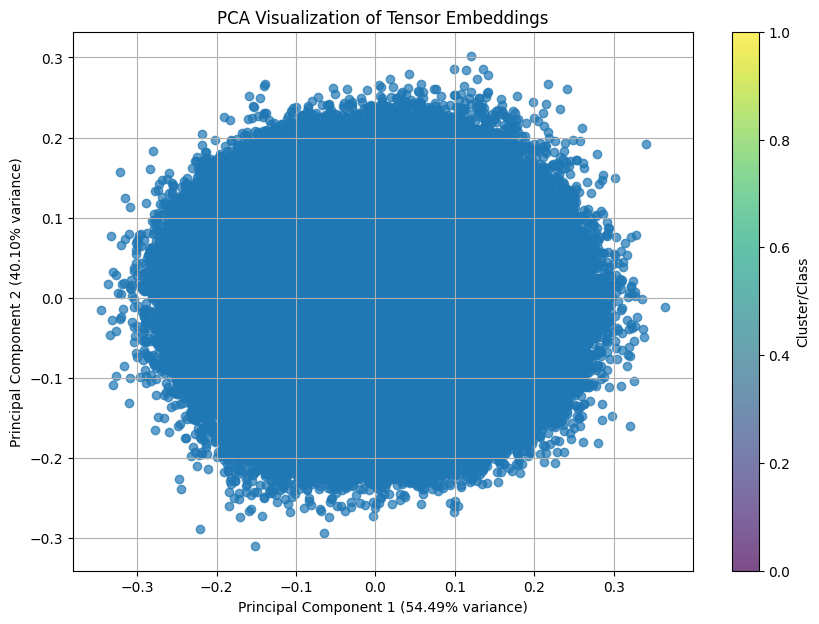

In [2]:
def visualize_pca(tensor_list, labels=None):
    """
    Takes a list of tensors, flattens them, performs PCA, and plots in 2D.
    """
    # 1. Convert tensors to a single numpy matrix (N, D)
    # Ensure all tensors are moved to CPU and flattened
    data = torch.stack([t.flatten() for t in tensor_list]).detach().cpu().numpy()
    # 2. Perform PCA to 2 components
    pca = PCA(n_components=2)
    components = pca.fit_transform(data)
    
    # 3. Plotting
    plt.figure(figsize=(10, 7))
    plt.scatter(components[:, 0], components[:, 1], c=labels, cmap='viridis', alpha=0.7)
    plt.title('PCA Visualization of Tensor Embeddings')
    plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
    plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
    plt.colorbar(label='Cluster/Class')
    plt.grid(True)
    plt.show()
visualize_pca([t for sample in list_for_kmeans for t in sample[0]])
#visualize_pca([t for sample in list_for_kmeans for sublist in sample[1:3] for t in sublist])

/tmp/ipykernel_471631/551833520.py:28: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap='viridis', alpha=0.6, s=10)


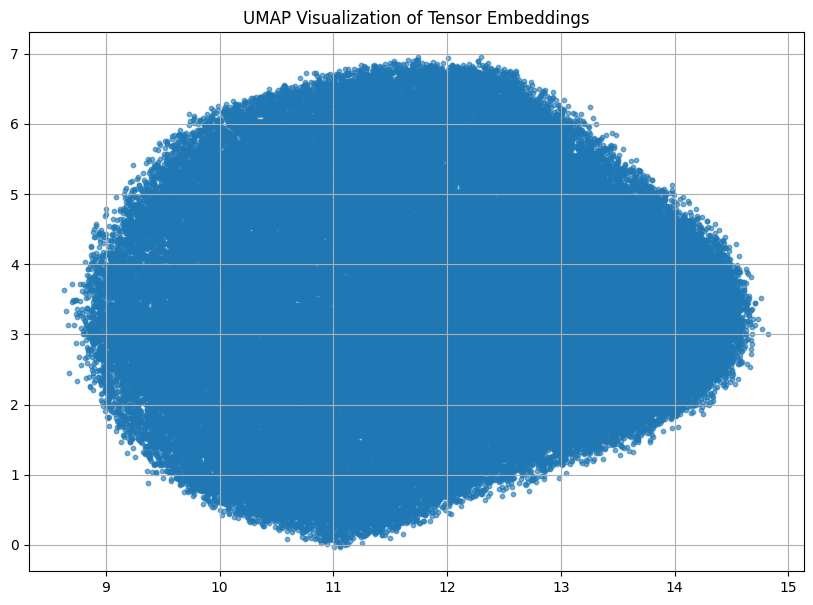

In [20]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap # Requires 'pip install umap-learn'

def visualize_manifold(tensor_list, labels=None, method='umap'):
    """
    Takes a list of tensors, flattens them, and performs non-linear projection.
    method: 'umap' or 'tsne'
    """
    # 1. Flatten and convert to numpy
    data = torch.stack([t.flatten() for t in tensor_list]).detach().cpu().numpy()
    
    # 2. Select the algorithm
    if method == 'umap':
        reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2)
    elif method == 'tsne':
        reducer = TSNE(n_components=2, perplexity=30, n_iter=1000)
    else:
        raise ValueError("Method must be 'umap' or 'tsne'")
        
    # 3. Perform the reduction
    embedding = reducer.fit_transform(data)
    
    # 4. Plotting
    plt.figure(figsize=(10, 7))
    plt.scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap='viridis', alpha=0.6, s=10)
    plt.title(f'{method.upper()} Visualization of Tensor Embeddings')
    plt.grid(True)
    plt.show()

# --- Example Usage ---
# Use the same list you prepared before
data = [t for sample in list_for_kmeans for sublist in sample[1:3] for t in sublist]
num_samples_to_visualize = 100000 
indices = np.random.choice(len(data), size=num_samples_to_visualize, replace=False)

# 2. Filter the data using the indices
# You must create a new list containing only the samples at those indices
subsampled_data = [data[i] for i in indices]

# 3. Pass the filtered data to your visualizer
visualize_manifold(subsampled_data, method='umap')